## Exemplo Introdutório de Redes Neurais Convolucionais (CNNs)

As Redes Neurais Convolucionais (CNNs) são uma classe de redes neurais profundas, mais comumente aplicadas à análise de imagens, mas também eficazes em outras tarefas como processamento de linguagem natural. Elas são projetadas para processar dados de pixel que têm uma topologia de grade conhecida, como imagens bidimensionais.

Este exemplo demonstrará uma CNN básica para classificar imagens do dataset Fashion MNIST.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import shap

### 1. Carregar e Pré-processar o Dataset Fashion MNIST

Vamos usar o dataset Fashion MNIST, que consiste em 70.000 imagens em tons de cinza de 28x28 pixels, de 10 categorias de itens de vestuário. 60.000 imagens são para treinamento e 10.000 para teste.

In [2]:
# Carregar o dataset Fashion MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalizar as imagens para o intervalo [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Redimensionar as imagens para o formato (largura, altura, canais)
# Para imagens em tons de cinza, o número de canais é 1.
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

class_names = ['T-shirt/Top', 'Calça', 'Suéter', 'Vestido', 'Jaqueta',
               'Sandália', 'Camisa', 'Tênis', 'Saia', 'Bota']

### 2. Visualizar algumas imagens

Vamos dar uma olhada nas primeiras 25 imagens do conjunto de treinamento e verificar seus rótulos.

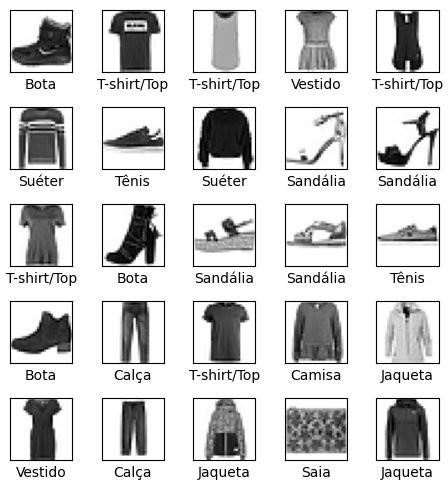

In [3]:
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
    plt.tight_layout()
plt.show()

### 3. Construir o Modelo CNN

Um modelo CNN típico consiste em:
- **Camadas Convolucionais (`Conv2D`):** Aplicam filtros para extrair características das imagens.
- **Camadas de Pooling (`MaxPooling2D`):** Reduzem a dimensionalidade das características, tornando o modelo mais robusto a pequenas variações e reduzindo o número de parâmetros.
- **Camadas Densas (`Dense`):** As camadas totalmente conectadas no final, usadas para a classificação final.

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compilar e Treinar o Modelo

Após definir a arquitetura do modelo, precisamos compilá-lo, especificando:
- **Otimizador:** Como o modelo será atualizado com base nos dados de treinamento (`'adam'` é um bom otimizador padrão).
- **Função de Perda:** Como o erro será medido (`SparseCategoricalCrossentropy` é adequada para classificação multiclasse quando os rótulos são inteiros).
- **Métricas:** Quais métricas serão monitoradas durante o treinamento e avaliação (`'accuracy'` é a mais comum para classificação).

Em seguida, treinamos o modelo usando os dados de treinamento.

In [5]:

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_split=0.2,callbacks=[early_stopping])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7874 - loss: 0.5726 - val_accuracy: 0.8612 - val_loss: 0.3803
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8693 - loss: 0.3588 - val_accuracy: 0.8824 - val_loss: 0.3255
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8865 - loss: 0.3107 - val_accuracy: 0.8943 - val_loss: 0.2923
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8969 - loss: 0.2811 - val_accuracy: 0.8966 - val_loss: 0.2826
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9046 - loss: 0.2590 - val_accuracy: 0.9043 - val_loss: 0.2657
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9098 - loss: 0.2411 - val_accuracy: 0.9051 - val_loss: 0.2632
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9157 - loss: 0.2269 - val_accuracy: 0.9060 - val_loss: 0.2623
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9197 - loss: 0.2140 -

### 5. Avaliar o Modelo

Após o treinamento, avaliamos o modelo no conjunto de teste para ver seu desempenho em dados que ele não viu durante o treinamento.

313/313 - 3s - 8ms/step - accuracy: 0.9069 - loss: 0.2736

Acurácia no conjunto de teste: 0.9069


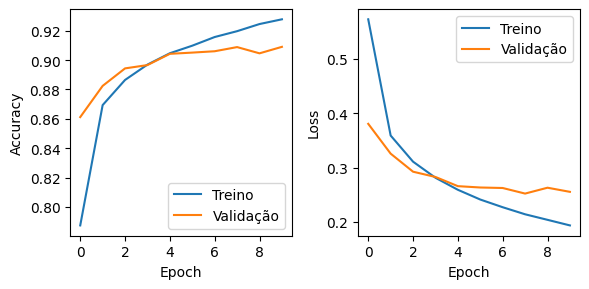

In [6]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label = 'Validação')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label = 'Validação')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.tight_layout()

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"\nAcurácia no conjunto de teste: {test_acc:.4f}")

### 6. Salvar o modelo para inferências ou testes futuros



## 7. IA explicável com SHAP

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(5, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 28, 28, 1))']
  warnings.warn(msg)


Classe prevista: Bota, Classe real: Bota


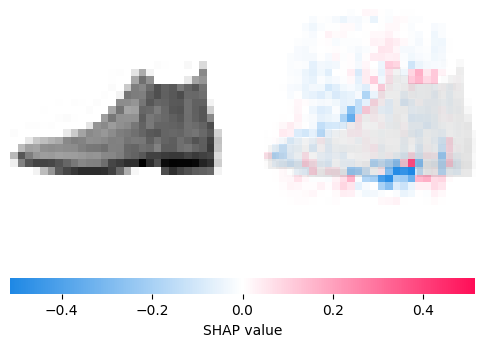

Classe prevista: Suéter, Classe real: Suéter


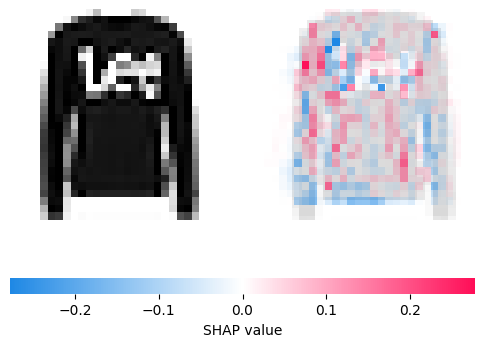

Classe prevista: Calça, Classe real: Calça


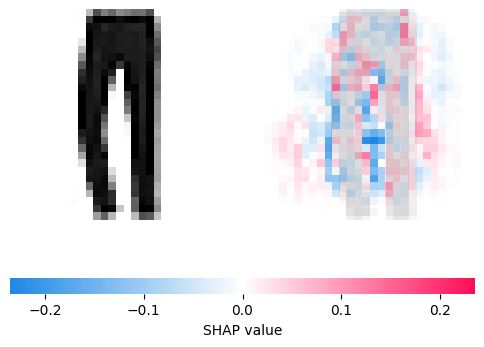

Classe prevista: Calça, Classe real: Calça


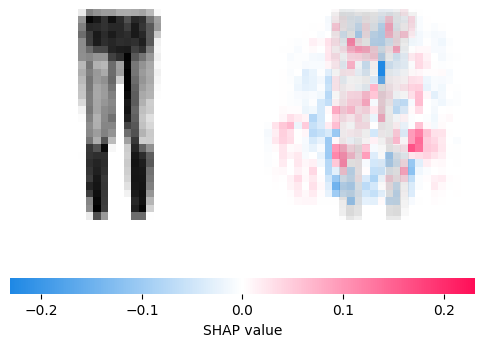

Classe prevista: Camisa, Classe real: Camisa


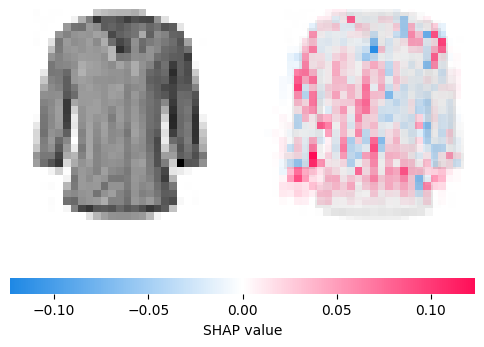

In [7]:
background = train_images[:100]
test_sample = test_images[:5]

preds = model.predict(test_sample)
pred_classes = np.argmax(preds, axis=1)
real_classes = test_labels[:5]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_sample)

for i in range(len(test_sample)):
    print(f"Classe prevista: {class_names[pred_classes[i]]}, Classe real: {class_names[real_classes[i]]}")
    shap.image_plot(shap_values[i, :, :, :, 0], -test_sample[i, :, :, :])




Mapas de calor SHAP (colunas da direita): Mostram como cada pixel contribuiu para a previsão do modelo.
Pixels em Vermelho (valores SHAP positivos): Indicam áreas que aumentaram a probabilidade do modelo classificar a imagem naquela categoria específica. No caso do suéter ou da bota, o formato das mangas ou do cano alto costuma concentrar pontos vermelhos porque são características marcantes dessas peças.
Pixels em Azul (valores SHAP negativos): Representam áreas que diminuíram a probabilidade de pertencer àquela classe (ou seja, regiões que o modelo interpretou como evidências contra aquela classificação).
Pixels em Cinza/Branco (valores SHAP próximos de zero): São partes da imagem que não influenciaram de forma significativa a decisão da rede neural (por exemplo, o fundo neutro da imagem).